# What is Exploratory Data Analysis (EDA)?

Exploratory Data Analysis (EDA) is the process of understanding and exploring a dataset before building machine learning models.

EDA helps identify:

- Data structure
- Missing values
- Outliers
- Distribution of variables
- Potential issues in the dataset

Performing EDA helps improve data quality and leads to better machine learning models.

In [1]:
import seaborn as sns

df = sns.load_dataset("titanic") #load the Titanic dataset from seaborn

df.head() #first 5 rows of the dataset
df.shape #number of rows and columns in the dataset
df.columns #list of columns in the dataset
df.info() #information about the dataset, including data types and missing values

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


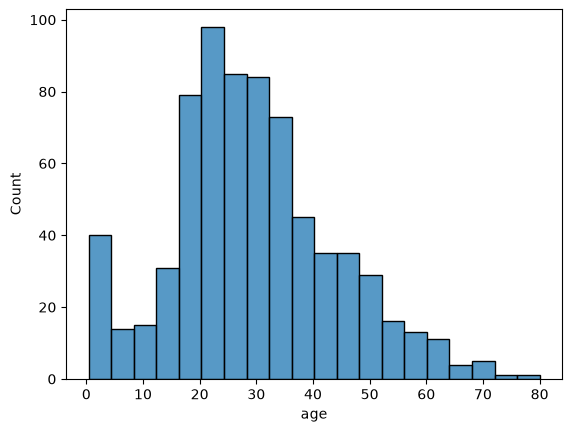

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df, x="age")
plt.show()

# Seaborn

Seaborn is a Python visualization library built on top of Matplotlib.

It provides simple functions for creating statistical charts such as:

- Histograms
- Box plots
- Count plots
- KDE plots

Seaborn works directly with Pandas DataFrames and is widely used for EDA.

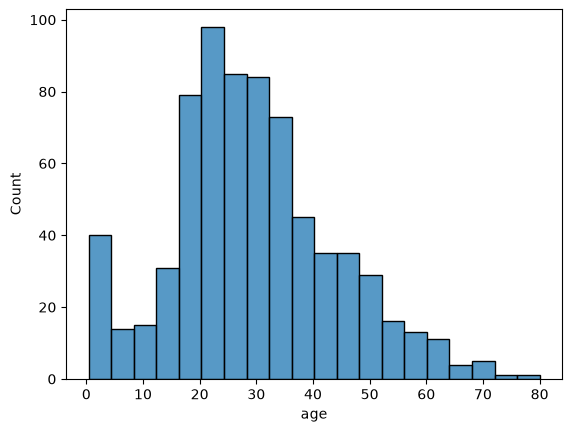

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="age")

plt.show()

# Univariate Analysis

Univariate analysis focuses on one variable at a time.

It helps understand:

- Distribution
- Frequency
- Spread
- Outliers

Common visualizations include:

- Histogram
- Box Plot
- Count Plot
- KDE Plot

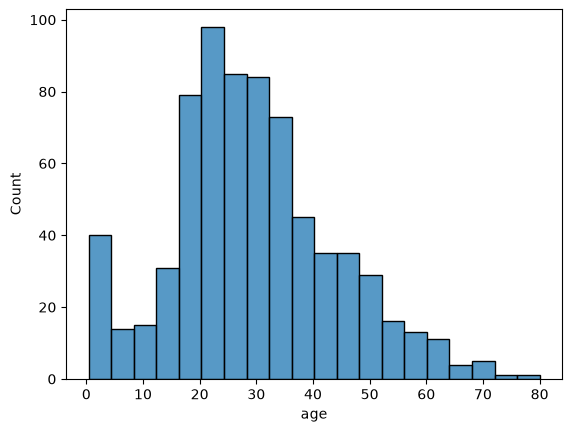

In [ ]:
sns.histplot(df["age"])
plt.show()

## Histogram

A histogram shows the distribution of a numerical variable.

It groups values into intervals (bins) and displays how many observations fall into each interval.

Histograms help identify:

- Shape of the distribution
- Skewness
- Peaks
- Spread

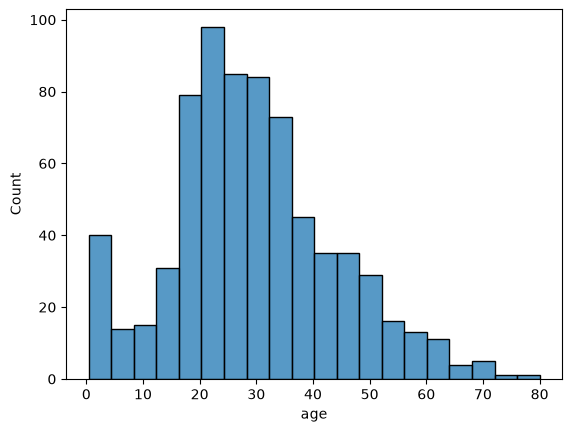

In [9]:
sns.histplot(df, x="age", bins=20)

plt.show()

## Box Plot

A box plot summarizes the distribution of a numerical variable.

It displays:

- Median
- Quartiles
- Interquartile Range (IQR)
- Potential outliers

It is commonly used to detect unusual values.

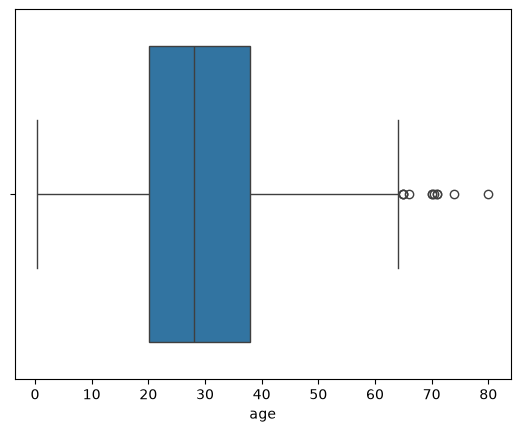

In [10]:
sns.boxplot(x=df["age"])

plt.show()

## Count Plot

A count plot displays the frequency of each category in a categorical variable.

It is useful for comparing the number of observations in different categories.

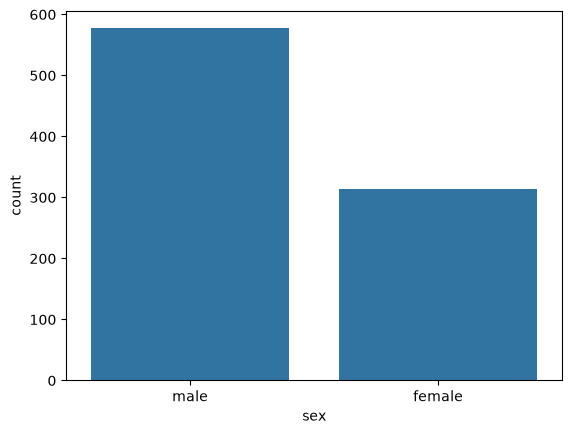

In [11]:
sns.countplot(data=df, x="sex")

plt.show()

## KDE Plot

A KDE (Kernel Density Estimate) plot provides a smooth estimate of a variable's distribution.

It is useful for visualizing the shape of numerical data without using histogram bars.

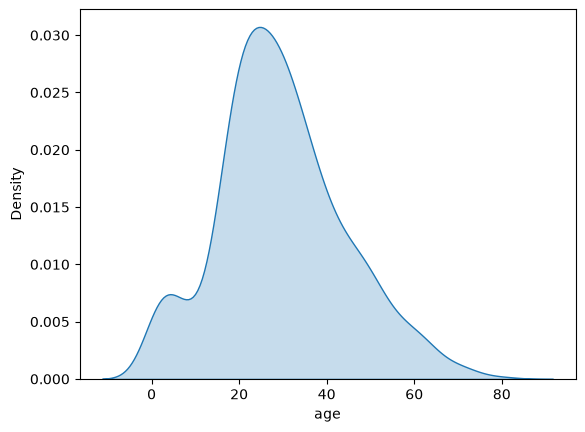

In [13]:
sns.kdeplot(df["age"], fill=True)

plt.show()

# Outliers

Outliers are observations that are much higher or lower than the rest of the data.

They may represent:

- Valid rare cases
- Data entry errors

Outliers should always be investigated before removing them.

# Detecting Outliers with IQR

The IQR method identifies outliers using quartiles.

Steps:

1. Calculate Q1 and Q3.
2. Compute IQR = Q3 − Q1.
3. Calculate lower and upper limits.
4. Values outside these limits are considered potential outliers.

Potential outliers should be reviewed before removal.

In [14]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["age"] < lower) | (df["age"] > upper)]

outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
456,0,1,male,65.0,0,0,26.5500,S,First,man,True,E,Southampton,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False


# Hands-On Lab: Univariate EDA on a Real Dataset

# Step 1: Histogram for Numeric Variables

In this step, I loaded the Titanic dataset and explored the distribution of all numerical variables using histograms.

Histograms help us understand:

- The shape of the distribution
- The spread of the data
- Whether the data is skewed
- Possible unusual values

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Titanic dataset
df = sns.load_dataset("titanic")

# Display all numeric columns
numeric_columns = df.select_dtypes(include="number").columns
numeric_columns

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')

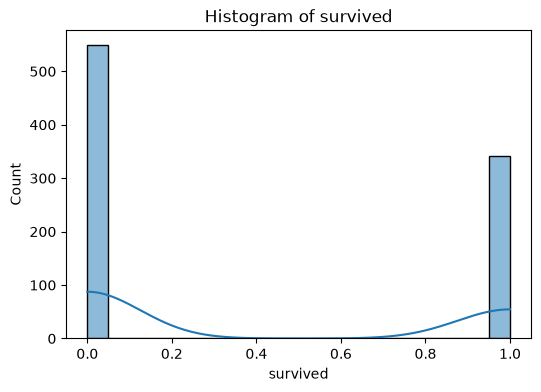

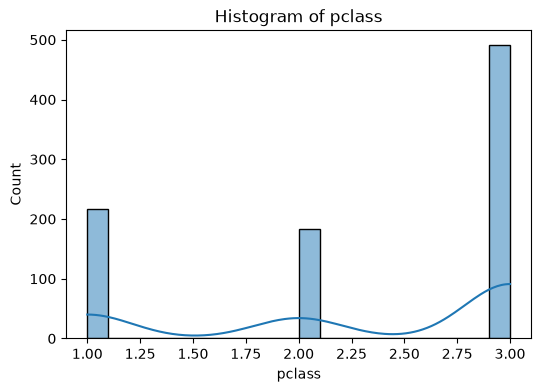

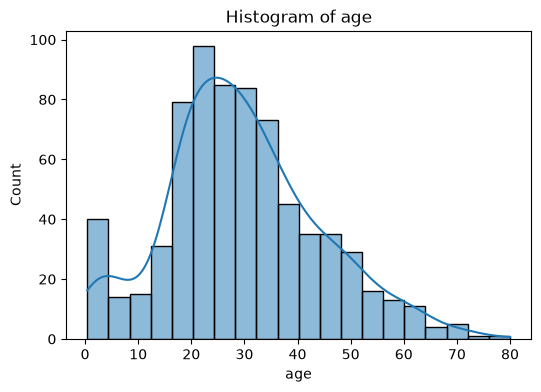

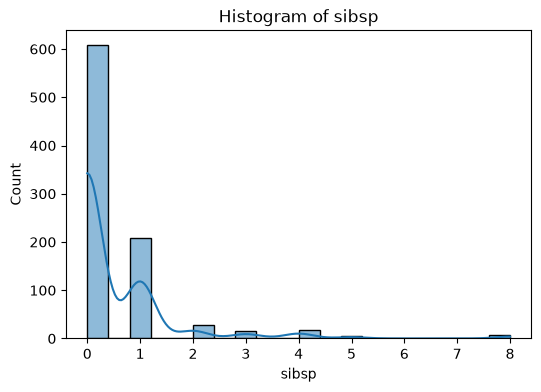

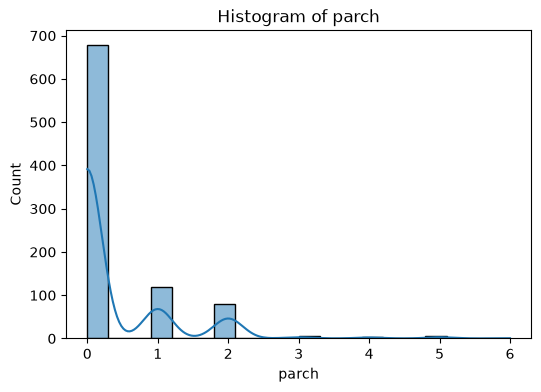

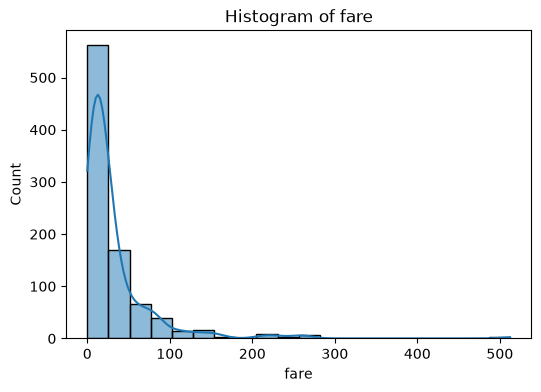

In [16]:
# Histogram for every numeric column

for column in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[column], bins=20, kde=True)
    plt.title(f"Histogram of {column}")
    plt.show()

### Observation

The histograms show that each numerical variable has a different distribution.

Some variables are approximately symmetric, while others are skewed. Histograms also help identify possible outliers and unusual distributions.

# Step 2: Box Plots

Box plots summarize the distribution of numerical variables and help detect potential outliers.

Points outside the whiskers are considered possible outliers.

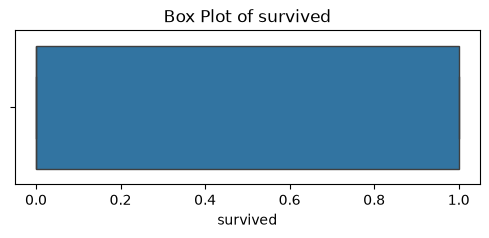

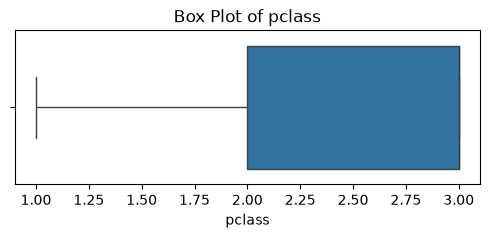

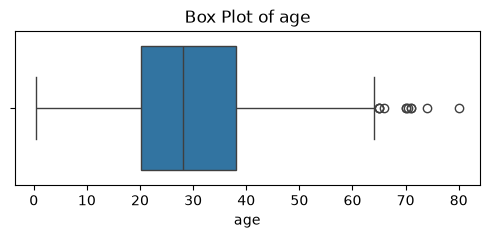

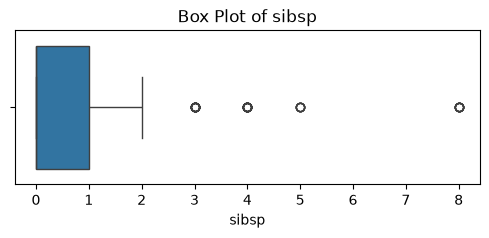

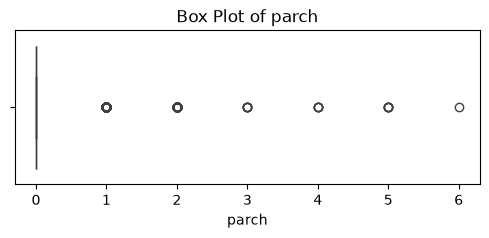

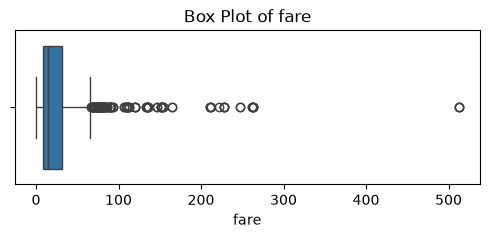

In [17]:
for column in numeric_columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

### Observation

Several numerical variables contain values outside the whiskers, indicating potential outliers.

The Fare column shows the clearest outliers because a small number of passengers paid much higher fares than the majority.

# Step 3: Detect Outliers Using the IQR Method

The Interquartile Range (IQR) method is used to detect potential outliers.

Values below the lower limit or above the upper limit are flagged as possible outliers.

In [18]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["fare"] < lower_limit) |
    (df["fare"] > upper_limit)
]

print("Number of outliers:", len(outliers))

outliers.head()

Number of outliers: 116


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False


### Observation

The Fare column contains several potential outliers.

These values most likely represent passengers who purchased expensive tickets rather than data entry errors.

Therefore, the outliers should be kept unless further investigation suggests they are incorrect.

# Step 4: Count Plots for Categorical Variables

Count plots display the frequency of each category.

They help identify class imbalance and understand the composition of categorical variables.

In [20]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
categorical_columns

Index(['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive'], dtype='str')

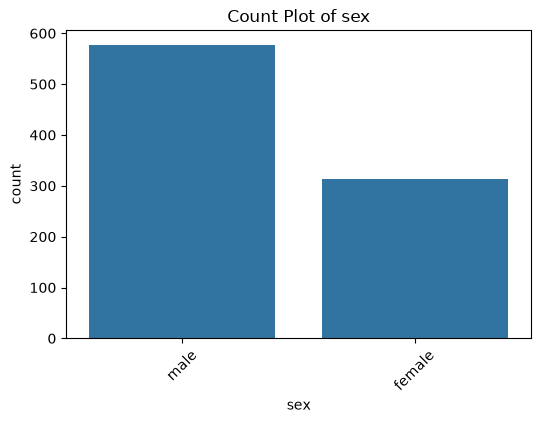

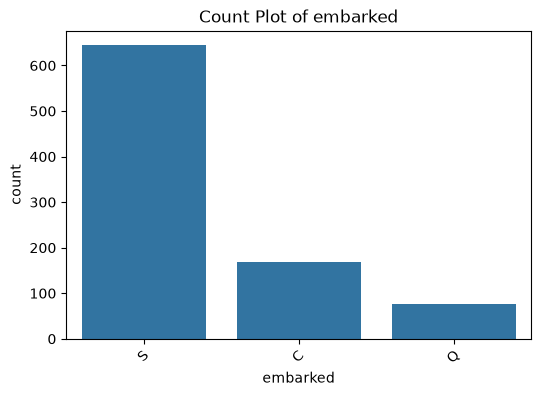

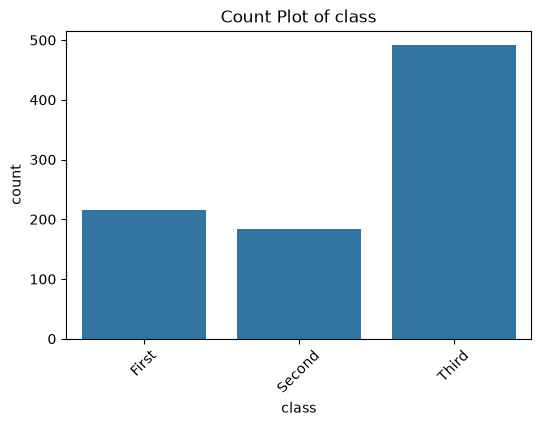

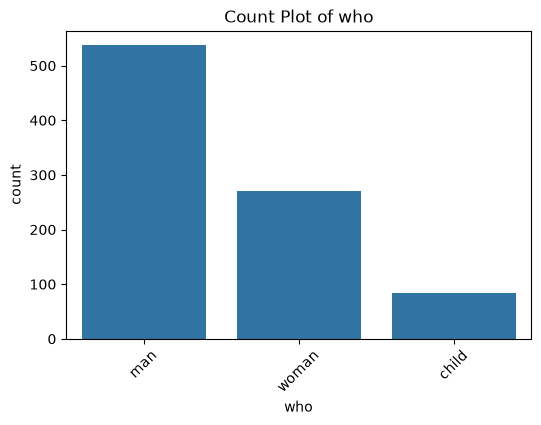

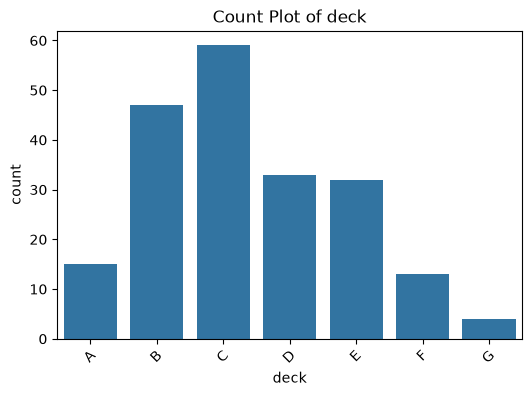

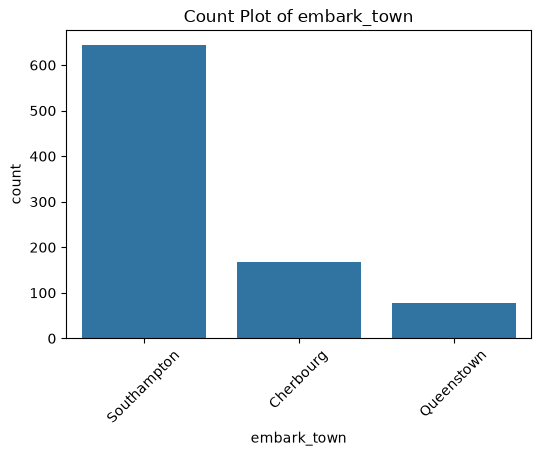

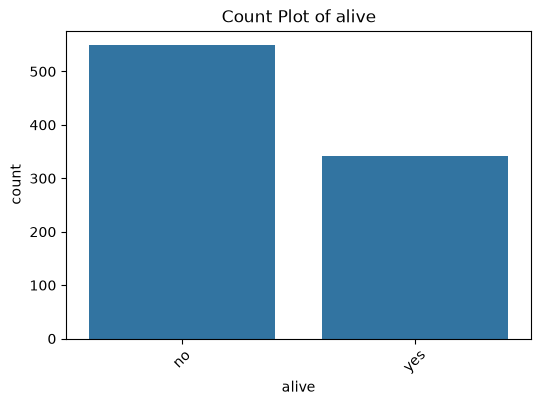

In [21]:
for column in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=column)
    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {column}")
    plt.show()

### Observation

The count plots show that some categories contain significantly more observations than others.

For example, there are more male passengers than female passengers, indicating a class imbalance in the Sex variable.

# Step 5: Summary

### Age
The age distribution is concentrated among young and middle-aged passengers.

### Fare
The Fare variable is right-skewed and contains several high-value outliers.

### Passenger Class
Most passengers traveled in the third class.

### Sex
There are more male passengers than female passengers.

### Embarked
Most passengers embarked from Southampton.

### Overall Conclusion

The Titanic dataset contains both numerical and categorical variables with different distributions.

Several numerical variables contain potential outliers, while categorical variables show some class imbalance.

Performing EDA provides valuable insights before building machine learning models.